Grammar Tuning in MLP Projections

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4183.99it/s]


Ready!


In [2]:
# Grammatically correct vs incorrect sentences
sentence_pairs = [
    ("The cat sits on the mat",      "The cat sit on the mat"),
    ("She walks to the store",       "She walk to the store"),
    ("He runs every morning",        "He run every morning"),
    ("The dog barks loudly",         "The dog bark loudly"),
    ("She writes beautiful poems",   "She write beautiful poems"),
]

# MLP FC activations 
def get_mlp_activations(text):
    inputs = tokenizer(text, return_tensors="pt")
    fc_activations = {}
    
    def make_hook(layer_idx):
        def hook(module, input, output):
            fc_activations[layer_idx] = output.detach()[0].mean(dim=0)
        return hook
    
    hooks = []
    for i in range(12):
        h = model.transformer.h[i].mlp.act.register_forward_hook(
            make_hook(i))
        hooks.append(h)
    
    with torch.no_grad():
        model(**inputs)
    
    for h in hooks:
        h.remove()
    
    return fc_activations

# Correct vs incorrect ke activations
correct_acts   = [get_mlp_activations(s[0]) for s in sentence_pairs]
incorrect_acts = [get_mlp_activations(s[1]) for s in sentence_pairs]

print(f"Captured activations for {len(sentence_pairs)} pairs!")
print(f"Each activation shape: {correct_acts[0][0].shape}")

Captured activations for 5 pairs!
Each activation shape: torch.Size([3072])


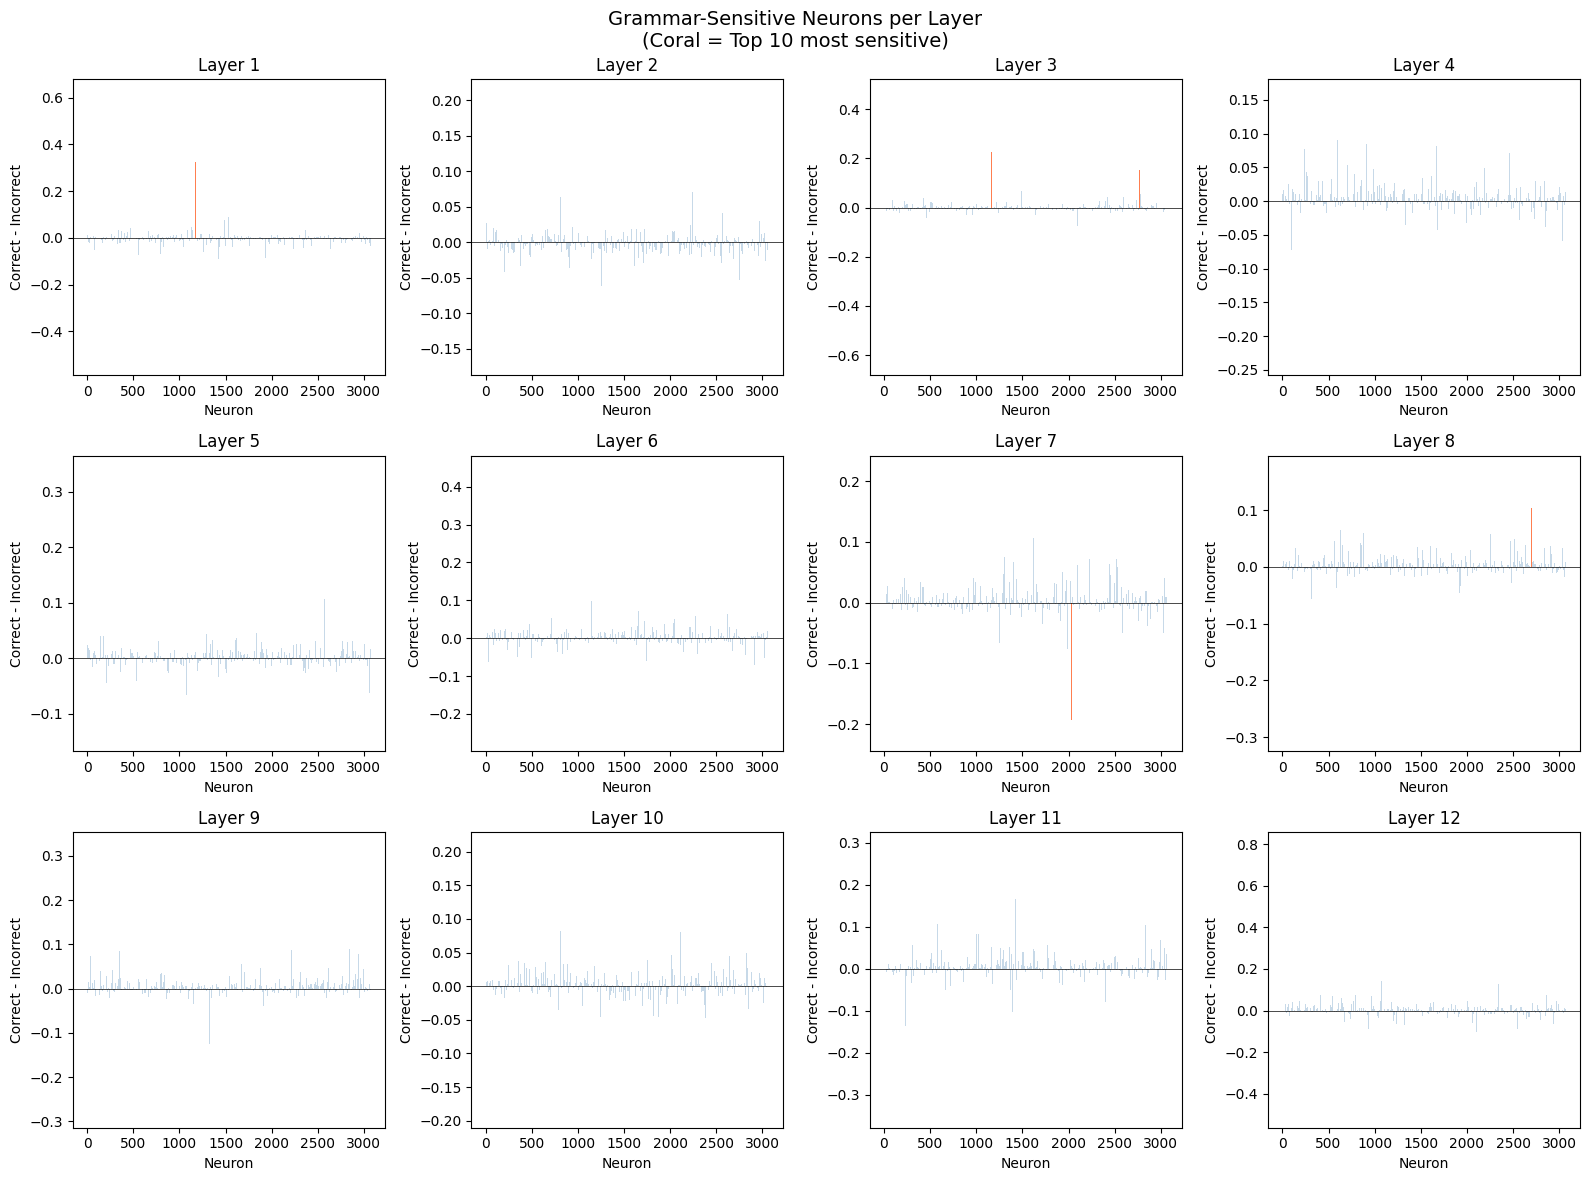

In [3]:

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for layer_idx, ax in enumerate(axes.flat):
    if layer_idx >= 12:
        break
    
    # Average correct aur incorrect activations
    avg_correct   = torch.stack([correct_acts[i][layer_idx] 
                                  for i in range(5)]).mean(dim=0)
    avg_incorrect = torch.stack([incorrect_acts[i][layer_idx] 
                                  for i in range(5)]).mean(dim=0)
    
    # Difference
    diff = (avg_correct - avg_incorrect).numpy()
    
    # Top 10 most different neurons
    top_neurons = np.argsort(np.abs(diff))[-10:]
    
    ax.bar(range(len(diff)), diff, color="steelblue", alpha=0.3)
    ax.bar(top_neurons, diff[top_neurons], color="coral")
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.set_title(f"Layer {layer_idx+1}")
    ax.set_xlabel("Neuron")
    ax.set_ylabel("Correct - Incorrect")

plt.suptitle("Grammar-Sensitive Neurons per Layer\n"
             "(Coral = Top 10 most sensitive)", fontsize=14)
plt.tight_layout()
plt.show()


* Each layer contains some grammar-sensitive neurons.
* Coral bars represent the top 10 most sensitive neurons.
* Different neurons in different layers track grammatical patterns.
* Grammatical knowledge is distributed across the MLP.
